[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nmickevicius/MCW_BIOP_03-238_MRI/blob/main/21_reconstruct_inversion_recovery/reconstruct.ipynb)

In [25]:
import numpy as np 
import h5py 
import matplotlib.pyplot as plt 
import os 
import torch 

def fft1d(inp, dim=0):
    if isinstance(inp, torch.Tensor):
        return torch.fft.fftshift(torch.fft.fft(torch.fft.fftshift(inp, dim=dim), dim=dim), dim=dim)
    elif isinstance(inp, np.ndarray):
        return np.fft.fftshift(np.fft.fft(np.fft.fftshift(inp, axes=(dim,)), axis=dim), axes=(dim,))

def ifft1d(inp, dim=0):
    if isinstance(inp, torch.Tensor):
        return torch.fft.ifftshift(torch.fft.ifft(torch.fft.ifftshift(inp, dim=dim), dim=dim), dim=dim)
    elif isinstance(inp, np.ndarray):
        return np.fft.ifftshift(np.fft.ifft(np.fft.ifftshift(inp, axes=(dim,)), axis=dim), axes=(dim,))
    
def fft2d(inp, dim=(0,1)):
    assert len(dim) == 2, 'Two dimensions must be specified for 2D FFT'
    return fft1d(fft1d(inp, dim[0]), dim[1])

def ifft2d(inp, dim=(0,1)):
    assert len(dim) == 2, 'Two dimensions must be specified for 2D inverse FFT'
    return ifft1d(ifft1d(inp, dim[0]), dim[1])



(96, 96, 32, 6)
(96, 96, 32)
(6,)
[0.041 0.059 0.084 0.167 0.337 0.48 ]
3.0


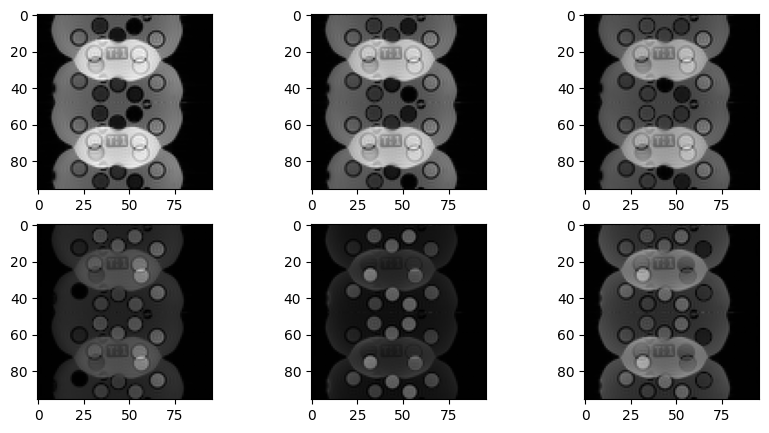

In [26]:
# load k-space data
fname = '/Users/nmickevicius/dev/MCW_BIOP_03-238_MRI/data/inversion_recovery_data.h5'
# !wget https://github.com/nmickevicius/MCW_BIOP_03-238_MRI/raw/main/data/inversion_recovery_data.h5
# fname = os.path.join(os.getcwd(), 'inversion_recovery_data.h5')
with h5py.File(fname, 'r') as F:
    ksp = F['ksp'][:]   # 2x-undersampled k-space data 
    sens = F['sens'][:] # coil sensitivity maps 
    TI = F['TI'][:]     # inversion times [sec]
    TR = F['TR'][()]    # repetition time [sec]

print(ksp.shape)
print(sens.shape) 
print(TI.shape)
print(TI)
print(TR)

# bring aliased k-space data to image domain 
img = ifft2d(ksp) 
rss = np.sqrt(np.sum(np.abs(img * img.conj()), axis=2))

# show the aliased images for each TI 
fig,ax = plt.subplots(2,3,figsize=(10,5))
for r in range(2):
    for c in range(3):
        ax[r,c].imshow(rss[:,:,r*3+c], cmap='gray', vmin=0.0, vmax=np.max(np.abs(rss)))
plt.show()

# In-Class Tasks

1. Perform a SENSE reconstruction to un-aliased the images at each inversion time
2. Estimate T1 in each voxel knowing the inversion times and reptition time

In [27]:

num_coils = 32 

recon = np.zeros((96, 96, 6), dtype=np.complex64)

for t in range(6):
    for c in range(96):
        for r in range(96//2):

            # Y vector aliased "folded-over" signal from each coil 
            BOBBY = img[r,c,:,t]

            # build the sensitivity encoding matrix 
            S = np.zeros((BOBBY.size, 2), dtype=np.complex64)
            S[:,0] = sens[r,c,:]
            S[:,1] = sens[r + 96//2, c, :]

            # solve the system of equation BOBBY = S FRANK
            FRANK = np.linalg.lstsq(S, BOBBY, rcond=None)[0]

            recon[r, c, t] = FRANK[0]
            recon[r + 96//2, c,t] = FRANK[1]

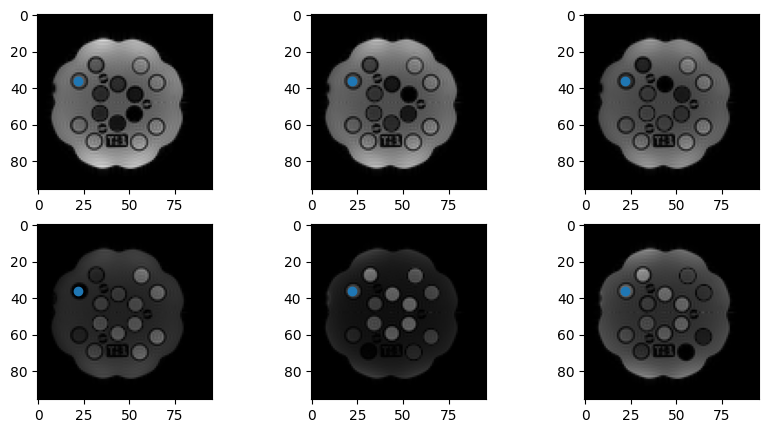

In [28]:
# show the aliased images for each TI 
fig,ax = plt.subplots(2,3,figsize=(10,5))
for r in range(2):
    for c in range(3):
        ax[r,c].imshow(np.abs(recon[:,:,r*3+c]), cmap='gray', vmin=0.0, vmax=np.max(np.abs(rss)))
        ax[r,c].scatter(22, 36)
plt.show()

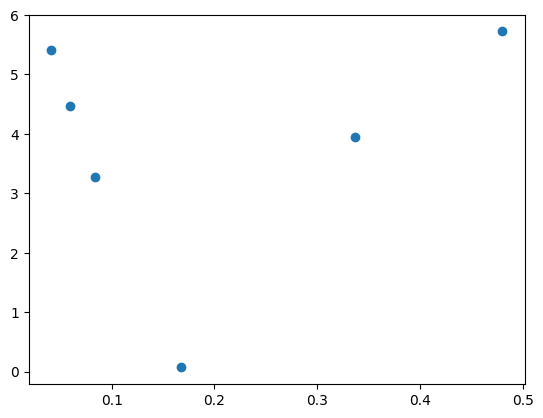

In [29]:
from scipy.optimize import minimize, Bounds

# row 36 col 22

plt.figure()
plt.scatter(TI, np.abs(recon[36,22,:]))
plt.show()

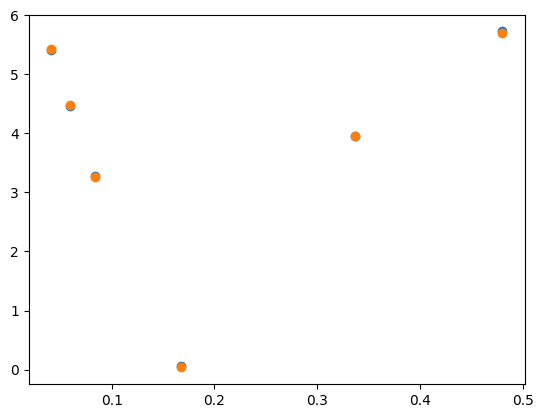

[7.87677072 0.24255419]


In [50]:
pixel = np.abs(recon[36,22,:])
alpha = np.pi/2
model = lambda x: np.abs(x[0]*np.sin(alpha)*(1-2*np.exp(-TI/x[1])+np.exp(-TR/x[1]))/(1+np.exp(-TR/x[1])*np.cos(alpha)))

def cost_function(x):
  JACKIE = model(x)
  return np.sum((JACKIE-pixel)**2)

T1_init = TI[np.argmin(pixel)] / np.log(2)
x0 = np.array([1.25 * np.max(np.abs(pixel)), T1_init])

# BARB = Bounds(lb=[0.05,0.05],ub=[20,2.0])
BARB = [(0.5, 20.0), (0.05, 3.0)]


result = minimize(cost_function, x0, bounds=BARB, method='trust-constr')
x = result.x
plt.figure()
plt.scatter(TI,pixel)
plt.scatter(TI,model(x))
plt.show()
print(x)

In [37]:
print(np.max(np.abs(recon)))

12.660761


In [41]:
m0_array = np.zeros((96,96))
t1_array = np.zeros((96,96))

for r in range(96):

  for c in range(96):

    pixel = np.abs(recon[r,c,:])
    
    def cost_function(x):
      JACKIE = model(x)
      return np.sum((JACKIE-pixel)**2)

    T1_init = TI[np.argmin(pixel)] / np.log(2)
    x0 = np.array([1.25 * np.max(np.abs(pixel)), T1_init])

    BARB = Bounds(lb=[0.05,0.1],ub=[20,3.0])
    BARB = [(0.5, 20.0), (0.05, 3.0)]
    
    result = minimize(cost_function,x0,bounds=BARB, method='trust-constr')
    m0_array[r,c]=result.x[0]
    t1_array[r,c]=result.x[1]


/var/folders/30/x3_16p4d5j5cq5v20dn6smqm0000gq/T/ipykernel_32009/1729397722.py:3: RuntimeWarning: overflow encountered in exp
  model = lambda x: np.abs(x[0]*np.sin(alpha)*(1-2*np.exp(-TI/x[1])+np.exp(-TR/x[1]))/(1+np.exp(-TR/x[1])*np.cos(alpha)))
/var/folders/30/x3_16p4d5j5cq5v20dn6smqm0000gq/T/ipykernel_32009/1729397722.py:3: RuntimeWarning: invalid value encountered in add
  model = lambda x: np.abs(x[0]*np.sin(alpha)*(1-2*np.exp(-TI/x[1])+np.exp(-TR/x[1]))/(1+np.exp(-TR/x[1])*np.cos(alpha)))
/var/folders/30/x3_16p4d5j5cq5v20dn6smqm0000gq/T/ipykernel_32009/1729397722.py:3: RuntimeWarning: invalid value encountered in divide
  model = lambda x: np.abs(x[0]*np.sin(alpha)*(1-2*np.exp(-TI/x[1])+np.exp(-TR/x[1]))/(1+np.exp(-TR/x[1])*np.cos(alpha)))


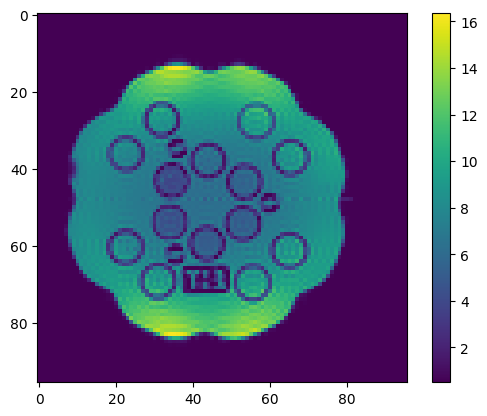

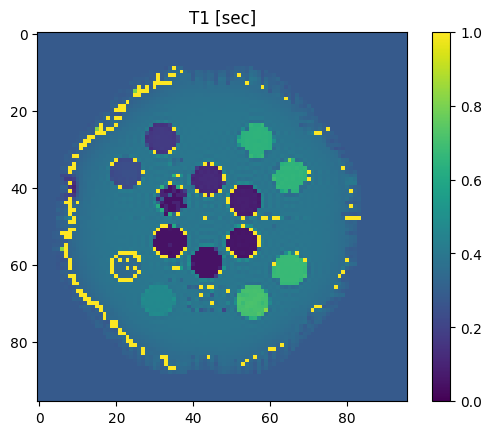

In [53]:
plt.figure()
plt.imshow(m0_array)
plt.colorbar()
plt.show()

plt.figure()
plt.imshow(t1_array, vmin=0.0, vmax=1.0)
plt.title('T1 [sec]')
plt.colorbar()
plt.show()